In [1]:
# Import library
from itertools import combinations
from sklearn.metrics import adjusted_rand_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import random
np.random.seed(42)
random.seed(42)

In [2]:
df= pd.read_csv("penguins_cleaned.csv")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,bill_length_mm_outlier,bill_depth_mm_outlier,flipper_length_mm_outlier,body_mass_g_outlier,is_any_outlier,body_mass_kg,bill_area_mm2,bill_ratio,flipper_mass_ratio
0,Adelie,Torgersen,39.10,18.7,181.0,3750.0,Male,False,False,False,False,False,3.75,731.170,2.090909,48.266667
1,Adelie,Torgersen,39.50,17.4,186.0,3800.0,Female,False,False,False,False,False,3.80,687.300,2.270115,48.947368
2,Adelie,Torgersen,40.30,18.0,195.0,3250.0,Female,False,False,False,False,False,3.25,725.400,2.238889,60.000000
3,Adelie,Torgersen,44.45,17.3,197.0,4050.0,Unknown,False,False,False,False,False,4.05,768.985,2.569364,48.641975
4,Adelie,Torgersen,36.70,19.3,193.0,3450.0,Female,False,False,False,False,False,3.45,708.310,1.901554,55.942029


In [3]:
all_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

In [22]:
# Baseline ARI (naively choose 4 initial features)
baseline_features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

X_base = df[baseline_features]
X_base_scaled = StandardScaler().fit_transform(X_base)

labels_base = KMeans(n_clusters=3, random_state=42).fit_predict(X_base_scaled)

ari_base = adjusted_rand_score(df['species'], labels_base)
print("Baseline ARI:", ari_base)

Baseline ARI: 0.7802764801745099


In [4]:
#Loop through all combinations
results = []

for r in range(2, len(all_features)+1):
    for combo in combinations(all_features, r):
        X = df[list(combo)]

        # scale
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # KMeans
        kmeans = KMeans(n_clusters=3, random_state=42)
        labels = kmeans.fit_predict(X_scaled)

        # ARI
        ari = adjusted_rand_score(df['species'], labels)

        results.append({
            'features': combo,
            'ARI': ari
        })

In [5]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ARI', ascending=False)

results_df.head(10)

,features,ARI
6,"(bill_length_mm, bill_depth_mm, flipper_length...",0.893866
1,"(bill_length_mm, flipper_length_mm)",0.873832
7,"(bill_length_mm, bill_depth_mm, body_mass_g)",0.865630
0,"(bill_length_mm, bill_depth_mm)",0.823125
10,"(bill_length_mm, bill_depth_mm, flipper_length...",0.780276
8,"(bill_length_mm, flipper_length_mm, body_mass_g)",0.667201
2,"(bill_length_mm, body_mass_g)",0.623350
3,"(bill_depth_mm, flipper_length_mm)",0.566406
9,"(bill_depth_mm, flipper_length_mm, body_mass_g)",0.551926
4,"(bill_depth_mm, body_mass_g)",0.539530


In [6]:
# Best combination
best_features = list(results_df.iloc[0]['features'])
print("Best features:", best_features)

Best features: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']


In [7]:
# Rerun pipeline
features = best_features
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

ari = adjusted_rand_score(df['species'], labels)
print("Best ARI:", ari)

Best ARI: 0.8938663174544567


In [17]:
# Evaluation
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled, labels)
print(sil_score)

0.4941504229962001


In [18]:
# Dimensionality reduction
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
df['cluster'] = labels

In [19]:
pca.explained_variance_ratio_

array([0.66761413, 0.25561397])

<BarContainer object of 2 artists>

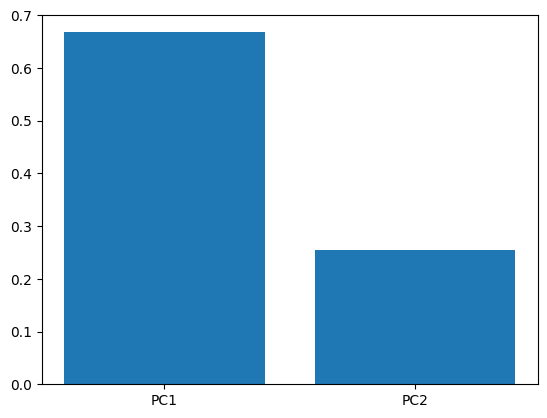

In [20]:
import matplotlib.pyplot as plt

plt.bar(['PC1', 'PC2'], pca.explained_variance_ratio_)

In [21]:
def plot_pca_clusters(df, sil_score, ari_score):
    import plotly.express as px

    fig = px.scatter(
        df,
        x='PC1',
        y='PC2',
        color='cluster',
        hover_data=['species', 'island', 'sex'],
        title=f"PCA Clustering | Silhouette: {sil_score:.2f} | ARI: {ari_score:.2f}"
    )

    return fig
plot_pca_clusters(df, sil_score, ari)

In [15]:
df.groupby('cluster')[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm
cluster,,,
0,38.638255,18.242953,189.463087
1,47.504878,14.982114,217.186992
2,48.750000,18.601389,196.708333


In [16]:
def plot_pca_species(df):
    import plotly.express as px

    fig = px.scatter(
        df,
        x='PC1',
        y='PC2',
        color='species',
        title="Ground Truth (Species)"
    )

    return fig
plot_pca_species(df)

In [23]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca, 'pca.pkl')

['pca.pkl']

In [24]:
df.to_csv("clustering_results.csv", index=False)